# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3723
      Test MAE: 5.11 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.3413
      Test MAE: 14.29 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.5001
      Test MAE: 18.29 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.8081
      Test MAE: 13.35 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.5542
      Test MAE: 70.68 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    feat_names = results[tier]['feature_names']
    coef_df = pd.DataFrame({
        'feature': feat_names,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    coef_df['coefficient'] = coef_df['coefficient'].apply(lambda x: '{:,.0f}'.format(x))
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                        feature coefficient
             inflicts_petrified          -1
            vulnerability_count          -1
             inflicts_paralyzed          -1
               inflicts_blinded          -1
               has_spellcasting          -1
         size_ordinal_deviation           1
            inflicts_frightened          -0
        has_regeneration_scaled          -0
    legendary_actions_per_round          -0
has_legendary_resistance_scaled           0

CR2 Top Features by Coefficient:
                    feature coefficient
           inflicts_charmed          -5
         inflicts_paralyzed          -5
     inflicts_incapacitated          -3
          inflicts_poisoned          -2
         inflicts_petrified          -2
     size_ordinal_deviation           1
        vulnerability_count           1
        inflicts_frightened          -0
legendary_actions_per_round           0
    has_regeneration_scaled           0

CR3 Top

## Investigate Specific Creatures

In [11]:
# [c for c in df.columns if 'hp' in c]

In [12]:
df[(df.has_flying==1) & (df.cr_numeric >= 5) & (df.cr_numeric <= 10)].sort_values('predicted_hp')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta_pct
241,Mage,6.0,40,37.302613,-6.743468
239,Young White Dragon,6.0,133,92.566667,-30.401003
250,Oni,7.0,110,98.551403,-10.407816
240,Young Brass Dragon,6.0,110,104.816667,-4.712121
262,Cloaker,8.0,78,109.285567,40.109701
248,Young Black Dragon,7.0,127,120.833333,-4.855643
242,Vrock,6.0,104,121.159623,16.499637
233,Air Elemental,5.0,90,121.171875,34.635417
256,Young Bronze Dragon,8.0,142,121.783333,-14.237089
244,Chimera,6.0,114,129.233333,13.362573


In [13]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Young Green Dragon', df, contributions_df)

  YOUNG GREEN DRAGON (CR 8.0)

Actual HP:             136
Predicted HP:          139
Error:                   3  (   2.4%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 8.0):                               163
  HP after Phase 1:                                     163

PHASE 2: COMBAT STATS

  Deviation Breakdown:
    Stat         Estimated   Feature    Total  Baseline  Deviation
    ------------------------------------------------------------
    AC                  18        +4       22        15         +7
    Attack               7        +0        7         7         +0
    DPR                 44       +13       57        53         +4
    Save DC             14        --       14        15         -1

  Costed DMG Features:
    feature_ac (+4):  saving_throws (4 saves) +2, flying (CR 8) +2
    feature_attack (+0):  (none)
    feature_dpr (+13):  (none)
    feature_hp (+0):  (none)

  HP Penalties:
    ac_

In [14]:
df[df['Name']=='Cloaker'][[c for c in df.columns if 'dpr' in c]]

,dpr_baseline,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,dpr_deviation
262,53.0,17.5,0.0,0,17.5,-35.5


In [15]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [16]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [17]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
             Name    CR  Actual_HP  Predicted_HP     Error
       Cockatrice 0.500         27     26.999999  0.000001
          Cultist 0.125          9      9.000002 -0.000002
         Commoner 0.000          4      4.125000 -0.125000
           Stirge 0.125          2      1.791082  0.208918
           Shadow 0.500         16     15.752861  0.247139
       Darkmantle 0.500         22     22.339369 -0.339369
         Warhorse 0.500         19     18.416959  0.583041
              Owl 0.000          1      0.416082  0.583918
             Wolf 0.250         11     10.250000  0.750000
Warhorse Skeleton 0.500         22     21.232320  0.767680

CR < 1 - Worst 10 Predictions:
           Name   CR  Actual_HP  Predicted_HP      Error
         Magmin 0.50          9     20.426791 -11.426791
     Giant Wasp 0.50         13     24.604240 -11.604240
      Hobgoblin 0.50         11     22.625000 -11.625000
          Scout 0.50         16     27.750000 -11.750000
   


CR 1-4 - Best 10 Predictions:
               Name  CR  Actual_HP  Predicted_HP     Error
           Basilisk 3.0         52     51.999931  0.000069
  Swarm of Quippers 1.0         28     28.875000 -0.875000
           Gargoyle 2.0         52     50.750000  1.250000
         Rhinoceros 2.0         45     46.447105 -1.447105
          Giant Elk 2.0         42     40.519210  1.480790
Saber-Toothed Tiger 2.0         52     50.447105  1.552895
           Minotaur 3.0         76     73.947105  2.052895
       Hunter Shark 2.0         45     47.072105 -2.072105
               Ogre 2.0         59     61.572105 -2.572105
            Pegasus 2.0         59     56.072105  2.927895

CR 1-4 - Worst 10 Predictions:
                  Name  CR  Actual_HP  Predicted_HP      Error
                Quasit 1.0          7     35.419801 -28.419801
                 Druid 2.0         27     56.400000 -29.400000
           Ochre Jelly 2.0         45     75.572105 -30.572105
               Specter 1.0         2

In [18]:
_df_check = analysis_dfs['cr2']
[c for c in _df_check.columns if 'immun' in c]


['hp_after_resist_immun_penalty',
 'immunity_count',
 'feature_spell_immunity',
 'feature_turn_immunity']

In [19]:
# _df_check = analysis_dfs['cr2']
# _df_check[_df_check['actual_hp'] == 45]



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


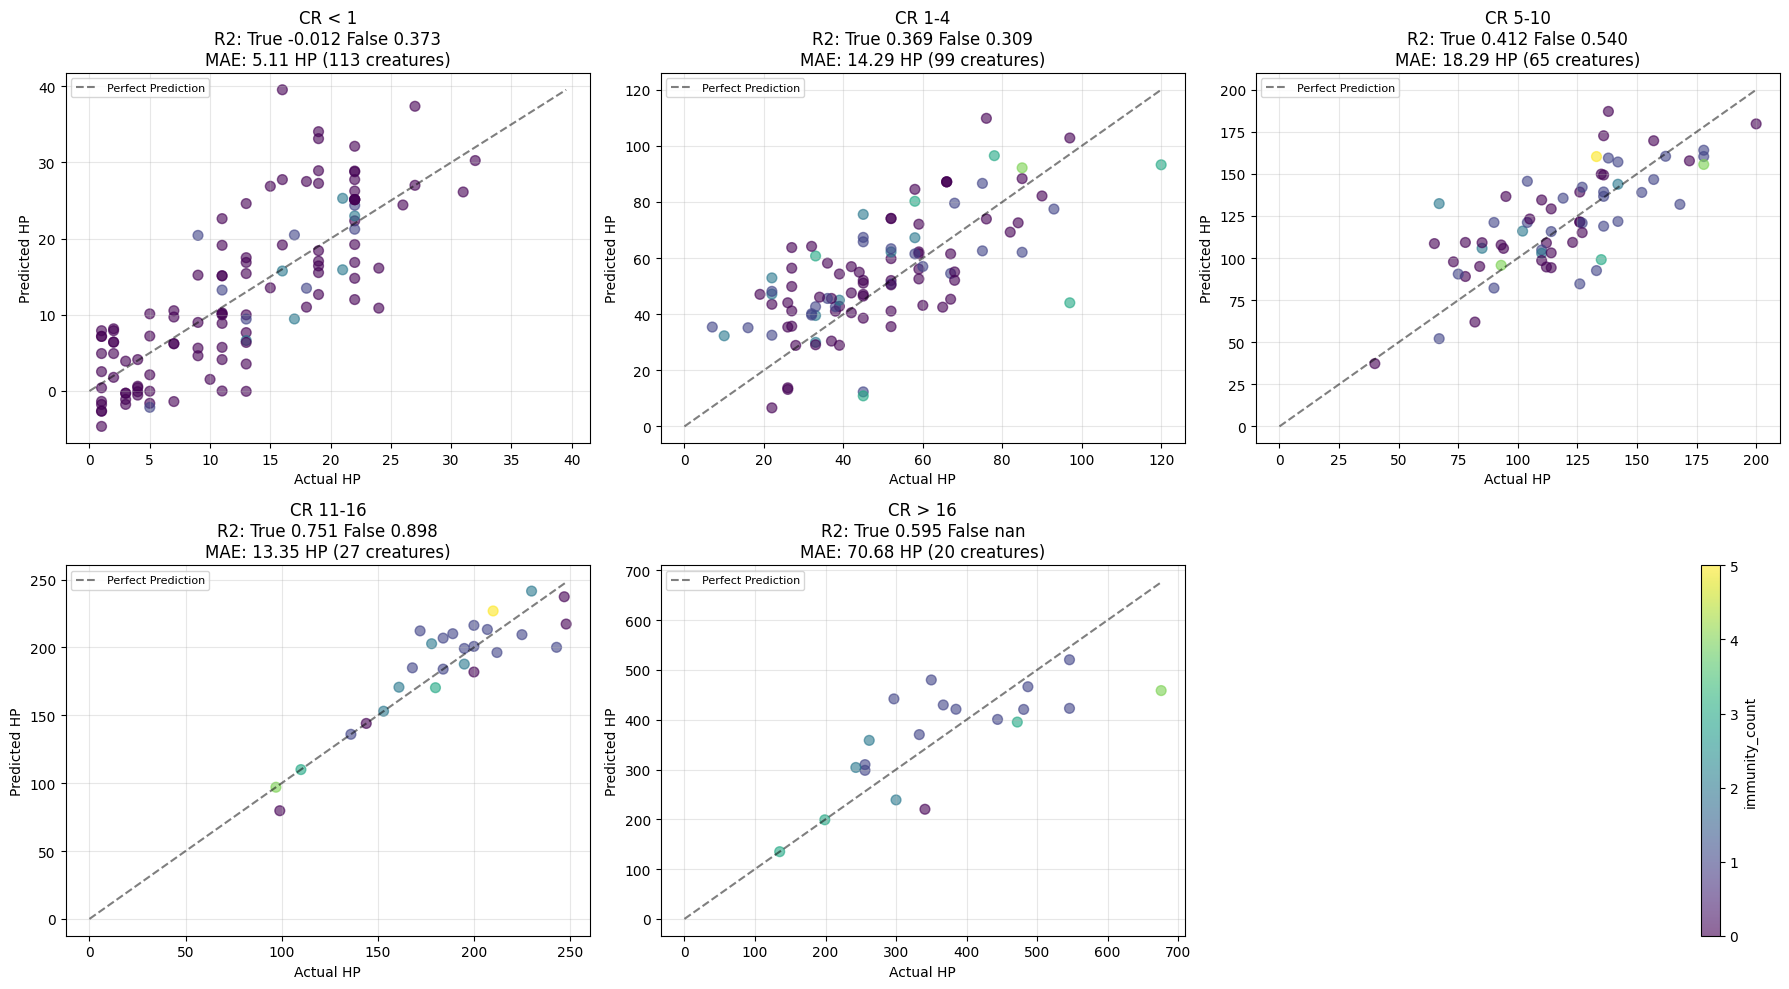

In [20]:
plot_performance_scatter(analysis_dfs, highlight_feature='immunity_count')

In [21]:
# for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
#     print(f"{k}: {v}")

In [22]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3723
      Test MAE: 5.11 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.3413
      Test MAE: 14.29 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.5001
      Test MAE: 18.29 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.8081
      Test MAE: 13.35 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.5542
      Test MAE: 70.68 HP

All 5 models trained successfully!



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


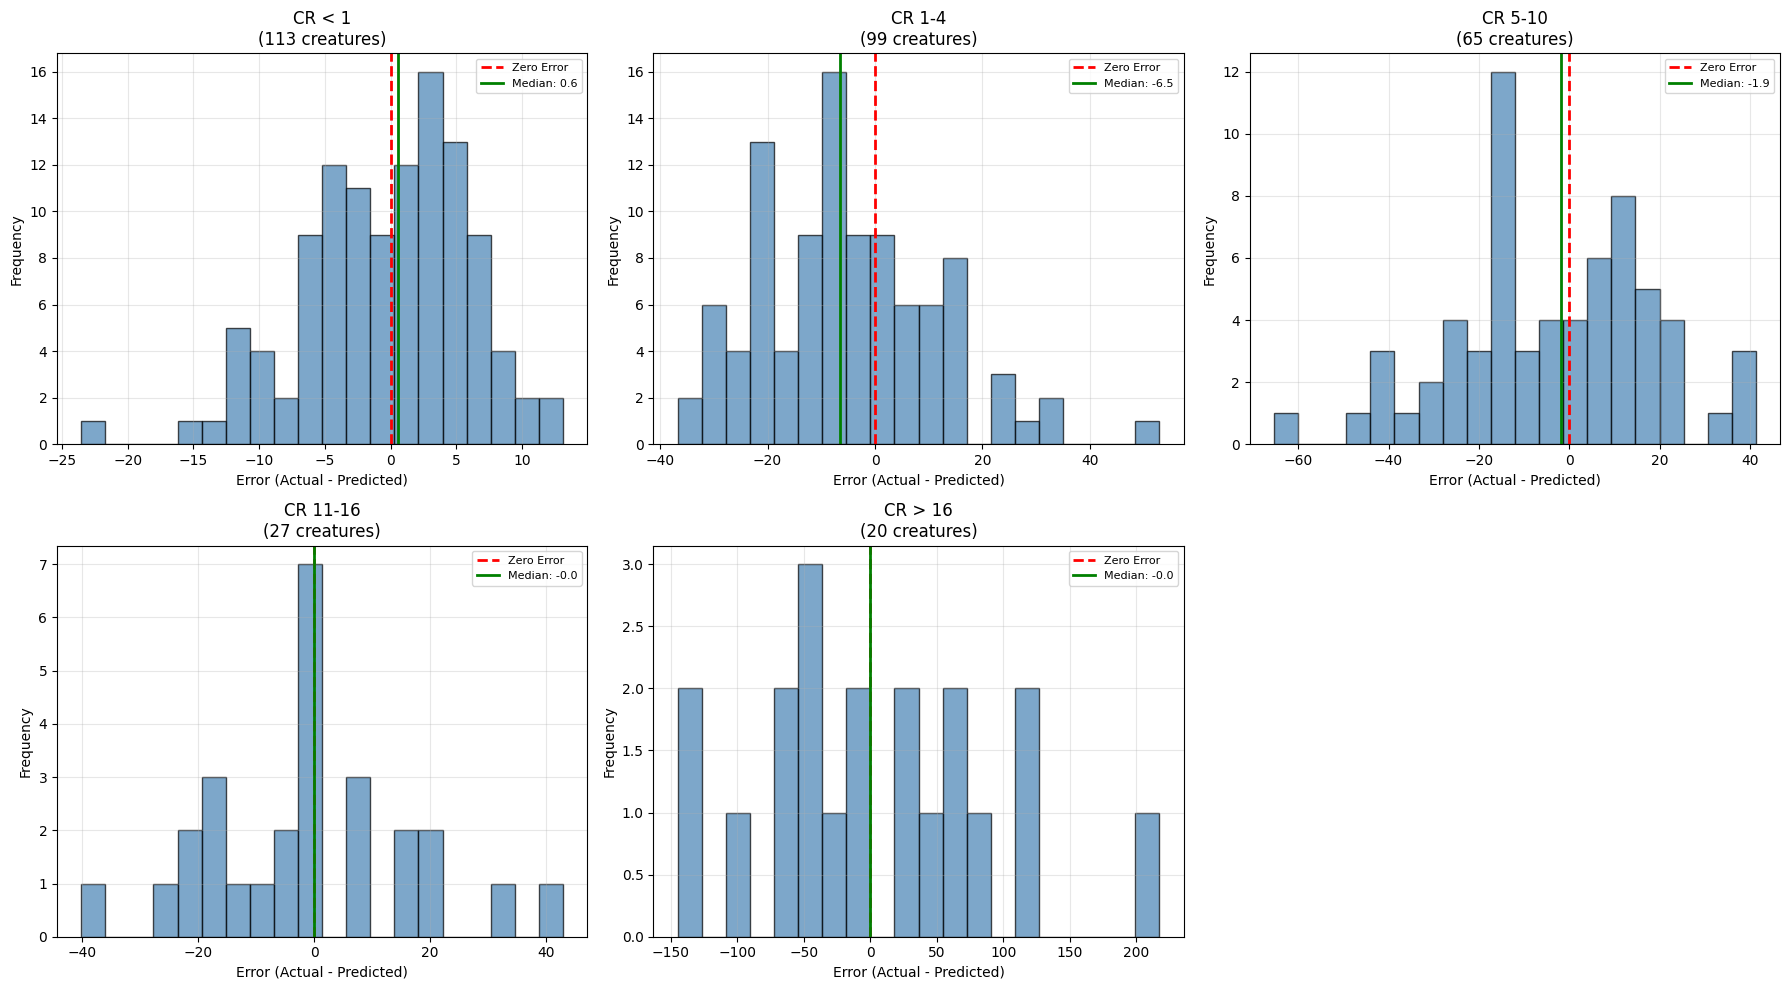

In [23]:
plot_error_hist(analysis_dfs)

# Feature Importance

In [24]:
importance_df = feature_importance_by_tier(contributions_df, df)

FEATURE IMPORTANCE BY CR TIER

  DMG INDIVIDUAL FEATURE COSTS (per-creature HP impact)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  legendary_resistance                        --         --         --      -90.0     -120.0
    (creature count)                          --         --         --          9         14
  damage_transfer                             --      -27.0      -81.6         --         --
    (creature count)                          --          1          1         --         --
  possession                                  --      -50.4         --         --         --
    (creature count)                          --          1         --         --         --
  blood_frenzy                              -8.0      -12.0      -16.0         --         --
    (creature count)                           2          2          1      

In [25]:
importance_df

,phase,feature,CR < 1,CR 1-4,CR 5-10,CR 11-16,CR > 16
0,DMG Features,legendary_resistance,0.000000,0.000000,0.000000,-90.000000,-120.000000
1,DMG Features,damage_transfer,0.000000,-27.000000,-81.600000,0.000000,0.000000
2,DMG Features,possession,0.000000,-50.400000,0.000000,0.000000,0.000000
3,DMG Features,blood_frenzy,-8.000000,-12.000000,-16.000000,0.000000,0.000000
4,DMG Features,magic_resistance,-3.000000,-5.000000,-7.000000,-9.000000,-12.000000
...,...,...,...,...,...,...,...
102,Phase 3,size_ordinal_deviation,-0.563465,1.438309,-0.623234,-1.938004,22.129899
103,Phase 3,inflicts_paralyzed,-5.895760,-17.357174,0.000000,0.000000,0.000000
104,Phase 3,inflicts_blinded,-5.618672,0.000000,-7.372880,-0.376673,0.000000
105,Phase 3,has_grapple,0.000000,0.000000,-4.943078,-3.117538,0.000000


In [26]:
df['actual_hp'].value_counts().head(10)

actual_hp
22    23
11    12
13    11
1     11
52    10
45    10
19    10
27     7
7      6
2      6
Name: count, dtype: int64